## PCA - Componente Pricipal de Análise

### data preprocessing

In [5]:
# Passo 1: carregar os dados
import pandas as pd

df = pd.read_csv('data/cleveland.csv', header = None)
print("shape:", df.shape)
display(df.sample(5))

shape: (303, 14)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
283,35,1,2,122,192,0,0,174,0,0.0,1,0.0,3.0,0
286,58,0,4,170,225,1,2,146,1,2.8,2,2.0,6.0,2
148,45,1,2,128,308,0,2,170,0,0.0,1,0.0,3.0,0
184,60,0,4,158,305,0,2,161,0,0.0,1,0.0,3.0,1
246,58,1,4,100,234,0,0,156,0,0.1,1,1.0,7.0,2


In [6]:
# Passo 2: balanceamento das classes
import pandas as pd

df = pd.read_csv('data/cleveland.csv', header = None)

df.columns = ['age', 'sex', 'cp', 'trestbps', 'chol',
  'fbs', 'restecg', 'thalach', 'exang', 
  'oldpeak', 'slope', 'ca', 'thal', 'target']
print("shape:", df.shape)
display(df.sample(5))

# Mapeia as classes transformando o problema em binário
df['target'] = df.target.map({0: 0, 1: 1, 2: 1, 3: 1, 4: 1})

### Verifica se há valores nulos
print("raw data:\n", df.isnull().sum().to_dict())

### Substitui os valores nulos pela média ##
df.fillna(df.mean(), inplace=True)

### Verifica se todos valores nulos foram substituidos
print("processed data:\n", df.isnull().sum().to_dict())

shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
31,60,1,4,117,230,1,0,160,1,1.4,1,2.0,7.0,2
93,44,0,3,108,141,0,0,175,0,0.6,2,0.0,3.0,0
32,64,1,3,140,335,0,0,158,0,0.0,1,0.0,3.0,1
9,53,1,4,140,203,1,2,155,1,3.1,3,0.0,7.0,1
35,42,1,4,140,226,0,0,178,0,0.0,1,0.0,3.0,0


raw data:
 {'age': 0, 'sex': 0, 'cp': 0, 'trestbps': 0, 'chol': 0, 'fbs': 0, 'restecg': 0, 'thalach': 0, 'exang': 0, 'oldpeak': 0, 'slope': 0, 'ca': 4, 'thal': 2, 'target': 0}
processed data:
 {'age': 0, 'sex': 0, 'cp': 0, 'trestbps': 0, 'chol': 0, 'fbs': 0, 'restecg': 0, 'thalach': 0, 'exang': 0, 'oldpeak': 0, 'slope': 0, 'ca': 0, 'thal': 0, 'target': 0}


In [2]:
## Separa os dados em treinamento e teste
from sklearn.model_selection import train_test_split

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

### training
Naive Bayes

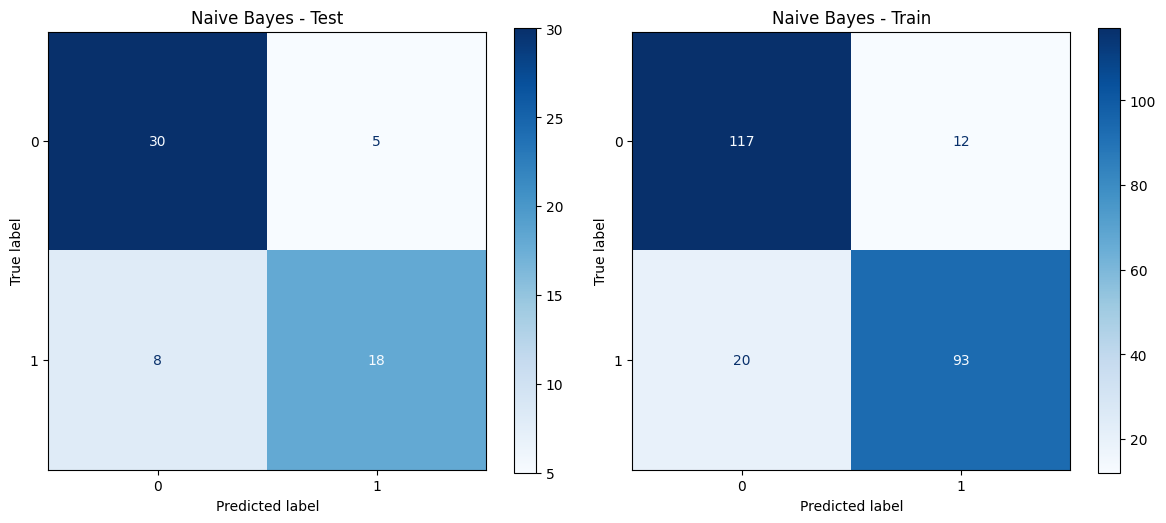

Accuracy for training set for Naive Bayes = 0.8677685950413223
Accuracy for test set for Naive Bayes = 0.7868852459016393


In [23]:
# Resultados
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
# Treinamento Modelo
classifier = GaussianNB()
classifier.fit(X_train, y_train)

# Teste modelo
y_pred_test = classifier.predict(X_test)
y_pred_train = classifier.predict(X_train)

# Calcular as matrizes de confusão
cm_test = confusion_matrix(y_test, y_pred_test)
cm_train = confusion_matrix(y_train, y_pred_train)

# Criar subplots
_, axes = plt.subplots(1, 2, figsize=(12, 5))

# Exibir a matriz de confusão para o conjunto de teste
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=classifier.classes_)
disp_test.plot(ax=axes[0], cmap=plt.cm.Blues)
axes[0].set_title('Naive Bayes - Test')

# Exibir a matriz de confusão para o conjunto de treino
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=classifier.classes_)
disp_train.plot(ax=axes[1], cmap=plt.cm.Blues)
axes[1].set_title('Naive Bayes - Train')

# Ajustar layout e mostrar gráficos
plt.tight_layout()
plt.show()

# Cálculo da acurácia para treino e teste
print('Accuracy for training set for Naive Bayes = {}'.format((cm_train[0][0] + cm_train[1][1]) / len(y_train)))
print('Accuracy for test set for Naive Bayes = {}'.format((cm_test[0][0] + cm_test[1][1]) / len(y_test)))

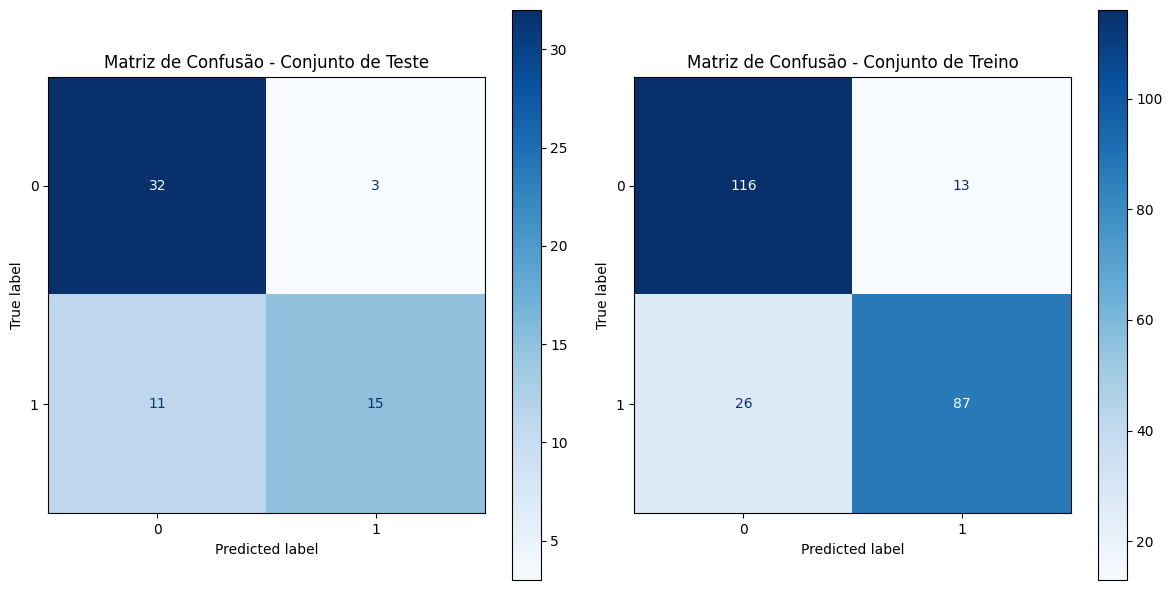

Acurácia para o conjunto de treino: 0.8388429752066116
Acurácia para o conjunto de teste: 0.7704918032786885


In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Passo 1: Normalizar os dados
#  ~~~~ Padronização (Z-Score) ~~~~
# Essa técnica transforma os dados de modo que eles tenham média zero e desvio padrão 1. 
# É útil quando seus dados têm uma distribuição aproximadamente normal e queremos que 
# todos os recursos tenham a mesma escala.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Passo 2: Aplicar PCA
pca = PCA(n_components=2)  
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Passo 3: Treinar o modelo 
classifier = GaussianNB()
classifier.fit(X_train_pca, y_train)

# Passo 4: Fazer previsões
y_pred_train = classifier.predict(X_train_pca)
y_pred_test = classifier.predict(X_test_pca)

# Passo 5: Criar matrizes de confusão
cm_train = confusion_matrix(y_train, y_pred_train)
cm_test = confusion_matrix(y_test, y_pred_test)

# Configurar subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))


# Matriz de Confusão - Conjunto de Teste
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=classifier.classes_)
disp_test.plot(ax=axes[0], cmap=plt.cm.Blues, values_format='d')
axes[0].set_title('Matriz de Confusão - Conjunto de Teste')

# Matriz de Confusão - Conjunto de Treino
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=classifier.classes_)
disp_train.plot(ax=axes[1], cmap=plt.cm.Blues, values_format='d')
axes[1].set_title('Matriz de Confusão - Conjunto de Treino')


plt.tight_layout()
plt.show()

# Cálculo da acurácia
accuracy_train = (cm_train[0][0] + cm_train[1][1]) / len(y_train)
accuracy_test = (cm_test[0][0] + cm_test[1][1]) / len(y_test)

print(f'Acurácia para o conjunto de treino: {accuracy_train}')
print(f'Acurácia para o conjunto de teste: {accuracy_test}')
